Assignment Questions

Q1. Handle Missing Values (Basic Cleaning)

Fill missing values using the following:

Age → Median

Salary → Mean

Hours_Worked_Per_Week → Median

Performance_Score → Mean

Display the dataset after handling missing values.



```

import pandas as pd

# Load dataset
df = pd.read_csv('Downloads/employee_productivity_dataset.csv')

# Display missing values before handling
print("Missing Values Before Handling:\n")
print(df.isnull().sum())

# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)

df['Salary'].fillna(df['Salary'].mean(), inplace=True)

df['Hours_Worked_Per_Week'].fillna(
    df['Hours_Worked_Per_Week'].median(),
    inplace=True
)

df['Performance_Score'].fillna(
    df['Performance_Score'].mean(),
    inplace=True
)

# Display dataset after handling missing values
print("\nDataset After Handling Missing Values:\n")
print(df)
```
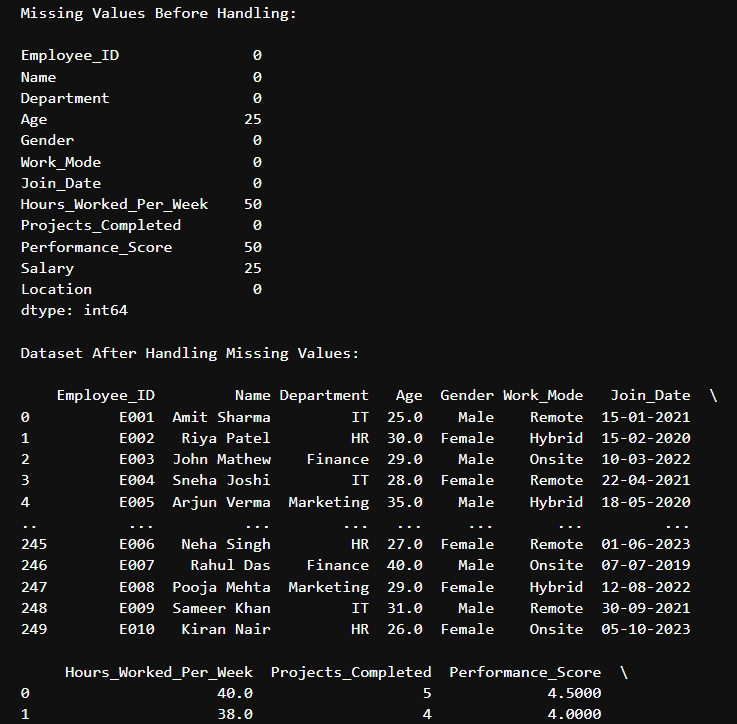

Q2. Label Encoding

Convert these columns into numeric values using Label Encoding:

Gender

Department

Show the updated columns.



```
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Apply Label Encoding
df['Gender'] = le.fit_transform(df['Gender'])

df['Department'] = le.fit_transform(df['Department'])

# Show updated columns
print("Updated Columns After Label Encoding:\n")
print(df[['Gender', 'Department']])
```
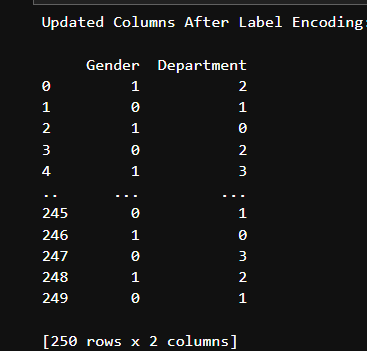

Q3. One-Hot Encoding

Apply One-Hot Encoding on:

Work_Mode

Location

Display the dataset and check how many new columns are created.



```
# Apply One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=['Work_Mode', 'Location'],
    drop_first=False
)

# Display updated dataset
print("Dataset After One-Hot Encoding:\n")
print(df)

# Check newly created columns
new_columns = [col for col in df.columns if 'Work_Mode_' in col or 'Location_' in col]

print("\nNew Columns Created:\n")
print(new_columns)

print("\nTotal New Columns Created:", len(new_columns))
```
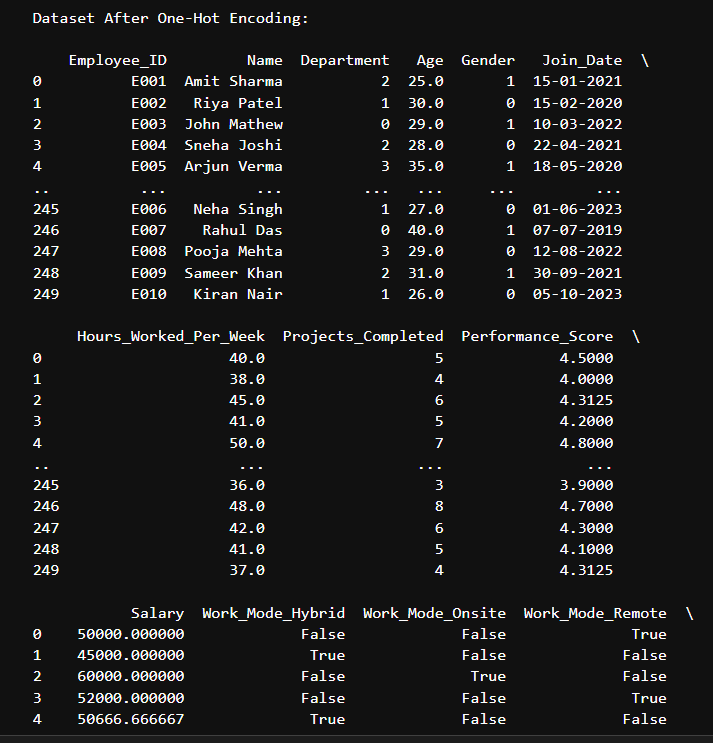

Q4. Normalization (Min-Max Scaling)

Normalize the following columns:

Salary

Hours_Worked_Per_Week

Use MinMaxScaler and display results.



```
from sklearn.preprocessing import MinMaxScaler

# Create scaler object
min_max_scaler = MinMaxScaler()

# Apply Min-Max Scaling
df[['Salary', 'Hours_Worked_Per_Week']] = min_max_scaler.fit_transform(
    df[['Salary', 'Hours_Worked_Per_Week']]
)

# Display normalized columns
print("Normalized Columns:\n")
print(df[['Salary', 'Hours_Worked_Per_Week']])
```
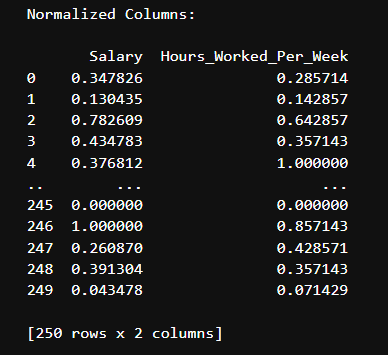

Q5. Standardization (Scaling)

Apply                                                                           Projects_Completed

Display the transformed values.



```

from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
standard_scaler = StandardScaler()

# Apply Standardization
df[['Projects_Completed']] = standard_scaler.fit_transform(
    df[['Projects_Completed']]
)

# Display transformed values
print("Standardized Values of Projects_Completed:\n")
print(df[['Projects_Completed']])
```
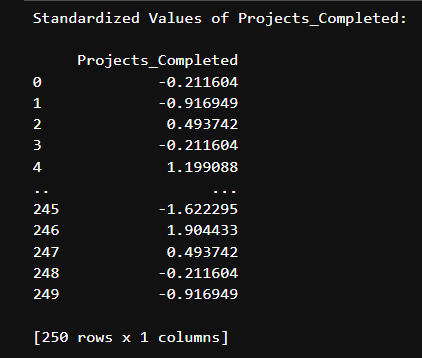

Q6. Compare Scaling Methods

Apply both:

MinMaxScaler

StandardScaler

On the Salary column.

Show both results side by side.



```
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Create scaler objects
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

# Create new columns for comparison
df['Salary_MinMax'] = minmax_scaler.fit_transform(df[['Salary']])

df['Salary_Standard'] = standard_scaler.fit_transform(df[['Salary']])

# Display results side by side
print("Comparison of Scaling Methods on Salary Column:\n")

print(df[['Salary', 'Salary_MinMax', 'Salary_Standard']])
```
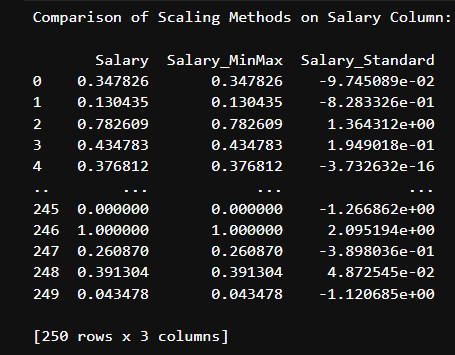


Q7. Build Preprocessing Pipeline

Create a pipeline that:

Applies encoding to categorical columns

Applies scaling to numerical columns

Use:

ColumnTransformer

Pipeline



```
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Separate categorical and numerical columns
categorical_columns = ['Gender', 'Department', 'Work_Mode', 'Location']

numerical_columns = [
    'Age',
    'Salary',
    'Hours_Worked_Per_Week',
    'Projects_Completed',
    'Performance_Score'
]

# Create preprocessing steps

# Categorical Pipeline
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Numerical Pipeline
numerical_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Combine pipelines using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_pipeline, categorical_columns),
    ('num', numerical_pipeline, numerical_columns)
])

# Apply preprocessing pipeline
processed_data = preprocessor.fit_transform(df)

# Display transformed data shape
print("Processed Data Shape:\n")
print(processed_data.shape)

# Display transformed dataset
print("\nProcessed Dataset:\n")
print(processed_data)
```
Q8. Apply Pipeline

Apply the pipeline on the dataset.

Display:

Transformed dataset

Shape of final dataset



```
import pandas as pd

# Apply the preprocessing pipeline
final_data = preprocessor.fit_transform(df)

# Convert transformed data into DataFrame
final_df = pd.DataFrame(final_data)

# Display transformed dataset
print("Transformed Dataset:\n")
print(final_df)

# Display shape of final dataset
print("\nShape of Final Dataset:")
print(final_df.shape)
```
Q9. Conceptual Question

Why is scaling important in Python?



```
Scaling is important because Machine Learning algorithms work better when all numerical features are in a similar range.

If one column has very large values and another has very small values, the model may give more importance to the larger values, which can reduce accuracy.


| Feature | Values         |
| ------- | -------------- |
| Salary  | 50000 – 100000 |
| Age     | 20 – 50        |


Benefits of Scaling
    Improves model performance

    Speeds up training

    Helps distance-based algorithms work correctly

    Prevents domination of large-value features

Algorithms that need scaling
   KNN

   SVM

   Logistic Regression

   Neural Networks

    K-Means Clustering
```



Q10. Conceptual Question

Why do we convert categorical data into numerical form?



```
Machine Learning models cannot understand text or categorical values directly.
They only work with numerical data.

Therefore, categorical data must be converted into numbers before training the model.

Example:

| Gender |
| ------ |
| Male   |
| Female |


After

| Gender |
| ------ |
| 1      |
| 0      |

Common Encoding Techniques:


| Technique        | Use                              |
| ---------------- | -------------------------------- |
| Label Encoding   | Converts categories into numbers |
| One-Hot Encoding | Creates separate binary columns  |

```



